##### Stock price prediction on one year of NVIDIA prices 

CSV data downloaded from Yahoo Finance: https://www.nasdaq.com/market-activity/stocks/nvda/historical
Time Period: 10yr

##### Cleaning the CSV data, sort in reverse order, and truncate to a year back from latest date

In [28]:
import pandas as pd
import aboodutils
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import classification_report


df = pd.read_csv("../../HistoricalData_1749770593630.csv")

df[df.columns[1:]] = df[df.columns[1:]].replace('[\$,]', '', regex=True).astype(float)

df = df.iloc[::-1]

df.reset_index(drop=True, inplace=True)

df = aboodutils.truncate_date(df, "05/10/2024", "Date", True)

df.head()


,Date,Close/Last,Volume,Open,High,Low
2243,05/10/2024,89.878,335325400.0,90.3045,91.401,89.227
2244,05/13/2024,90.399,289680200.0,90.4780,90.998,88.529
2245,05/14/2024,91.356,296507100.0,89.5990,91.651,88.934
2246,05/15/2024,94.630,417735500.0,92.4720,94.862,91.599
2247,05/16/2024,94.359,323951800.0,94.9100,95.819,94.103


### Plot initial data after cleaning

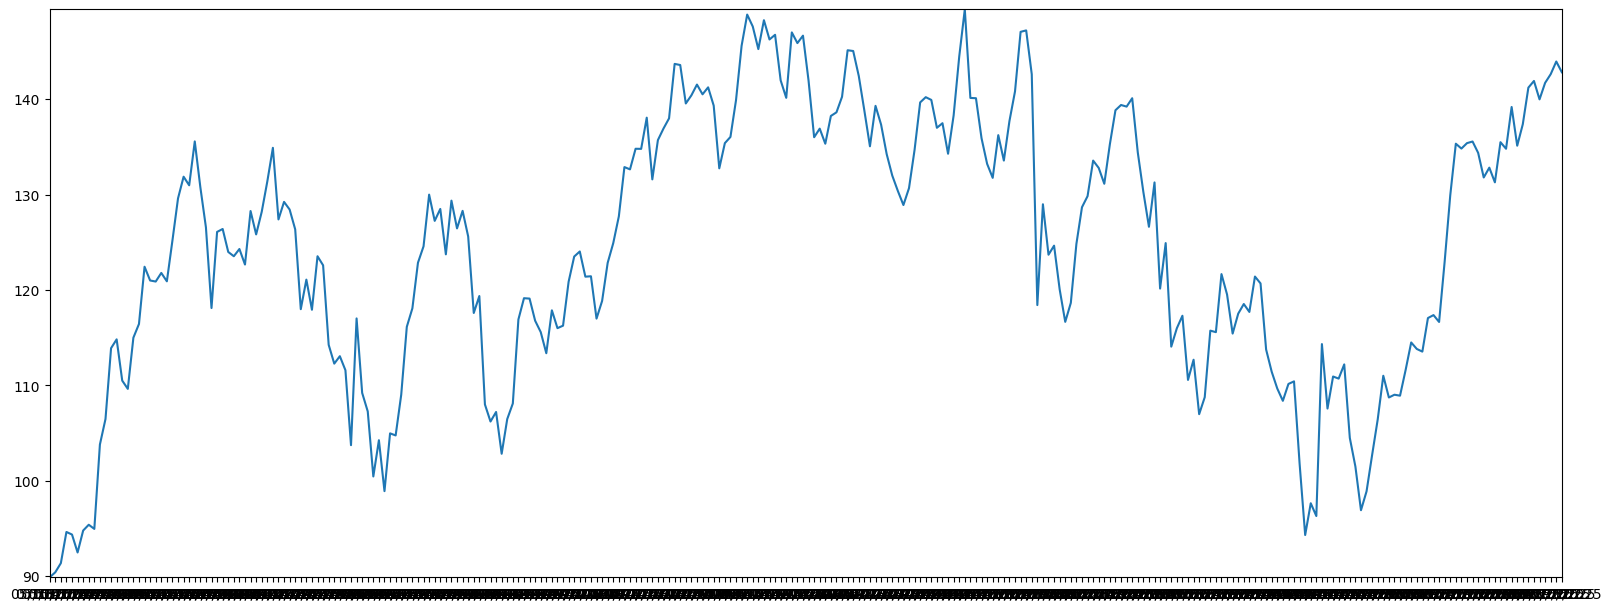

In [29]:
plotdf = df.drop(["Volume", "Open", "High", "Low"], axis=1)

fig, ax = plt.subplots(layout="constrained")
fig.set_size_inches(16, 6)
ax.autoscale(enable=True, axis='both', tight=True)

ax.plot(plotdf["Date"], plotdf["Close/Last"])


#### Plot the sanitized data

In [30]:
y = df["Close/Last"]
X = df.drop(columns=["Date", "Close/Last"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgbr = XGBRegressor(verbosity=0)

xgbr.fit(X_train, y_train)

y_pred = xgbr.predict(X_test)

ax.plot(y_pred)

#### Plot forecast

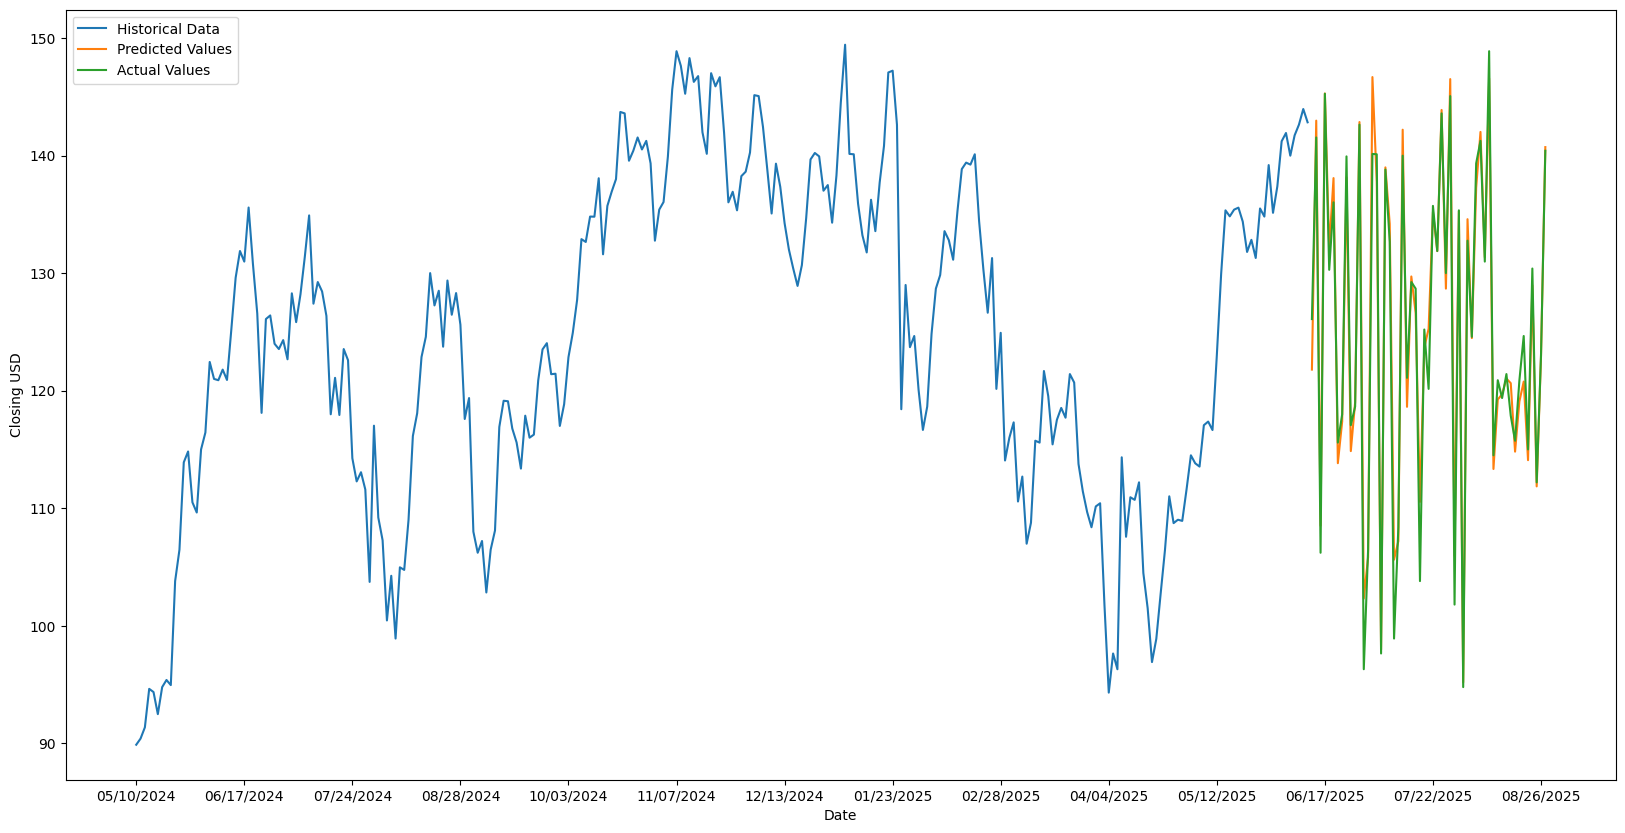

In [31]:
periods = len(y_pred)
fut_range = pd.date_range("2025-06-12", periods=periods, freq="B")

pred_df = pd.DataFrame({"Date": fut_range, "Close/Last": y_pred})
test_df = pd.DataFrame({"Date": fut_range, "Close/Last": y_test})


pred_df["Date"] = pred_df["Date"].dt.strftime('%m/%d/%Y')
test_df["Date"] = test_df["Date"].dt.strftime('%m/%d/%Y')


fig, ax = plt.subplots()

fig.set_size_inches(20, 10)
ax.set_xlabel("Date")
ax.set_ylabel("Closing USD")

ax.plot(plotdf["Date"], plotdf["Close/Last"])
ax.plot(pred_df["Date"], pred_df["Close/Last"])
ax.plot(test_df["Date"], test_df["Close/Last"])

ax.xaxis.set_major_locator(plt.MultipleLocator(25))
ax.legend(["Historical Data", "Predicted Values", "Actual Values"])



#### Output data to CSVs

In [32]:
pred_df.to_csv("output/pred.csv")
test_df.to_csv("output/test.csv")

## Generate Results

In [33]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print(mape)

0.014749201575832298


| Metric | Result |
|------|--------|
| MAPE | 15%    |


# Conclusion: the model was approx 85% accurate in its predictions